In [ ]:
#2.2
import numpy as np

# 设置随机种子
np.random.seed(42)

# 1. 创建一个形状为 3x4 的随机整数矩阵 X

X = np.random.randn(3, 4)  # 标准正态分布
X = np.round(X).astype(int)  # 取整为整数
print("矩阵 X (3x4):\n", X)

# 2. 创建一个形状为 4x2 的全 1 矩阵 Y
Y = np.ones((4, 2), dtype=int)
print("\n矩阵 Y (4x2):\n", Y)

# 3. 计算矩阵乘法 Z = X @ Y
Z = X @ Y
print("\n矩阵乘积 Z = X @ Y (3x2):\n", Z)

# 4. 输出 Z 的(0,1)位置的数
print("\nZ 的(0,1)位置的元素:", Z[0, 1])   # 索引：行0，列1
print("Z 的(1,:)位置的所有元素:", Z[1, :])            # 索引：行1

# 5. 计算 Z 的 Frobenius 范数
fro_norm = np.linalg.norm(Z, 'fro')
print("Z 的 Frobenius 范数:", fro_norm)

矩阵 X (3x4):
 [[0 0 1 2]
 [0 0 2 1]
 [0 1 0 0]]

矩阵 Y (4x2):
 [[1 1]
 [1 1]
 [1 1]
 [1 1]]

矩阵乘积 Z = X @ Y (3x2):
 [[3 3]
 [3 3]
 [1 1]]

Z 的第一行第二列交叉处元素: 3
Z 的第二行所有元素: [3 3]
Z 的 Frobenius 范数: 6.164414002968976


In [7]:
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示为方块的问题

3.2

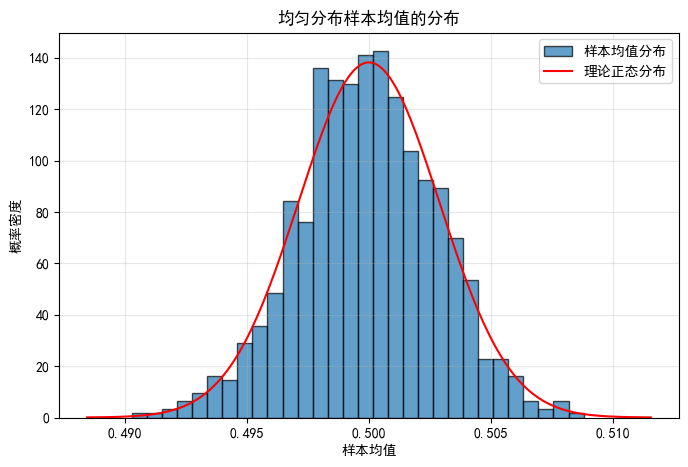

实际方差: 0.000008
理论方差: 0.000008


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 参数设置
n = 10000      # 每次抽样的样本量
m = 1000       # 重复次数

# 模拟：生成 m 次，每次 n 个 U(0,1) 的均值
means = np.zeros(m)
for i in range(m):
    samples = np.random.uniform(0, 1, n)
    means[i] = np.mean(samples)

# 绘制直方图
plt.figure(figsize=(8, 5))
plt.hist(means, bins=30, density=True, alpha=0.7, edgecolor='black', label='样本均值分布')

# 理论正态分布：均值 = 0.5，方差 = (1/12) / n
mu_theory = 0.5
sigma_theory = np.sqrt((1/12) / n)
x = np.linspace(mu_theory - 4*sigma_theory, mu_theory + 4*sigma_theory, 200)
plt.plot(x, norm.pdf(x, mu_theory, sigma_theory), 'r-', label='理论正态分布')

plt.xlabel('样本均值')
plt.ylabel('概率密度')
plt.title('均匀分布样本均值的分布')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 计算实际方差
actual_var = np.var(means, ddof=0)   # 总体方差（有偏）
print(f"实际方差: {actual_var:.6f}")
print(f"理论方差: {(1/12)/n:.6f}")

4.2

In [ ]:

import torch

# 手动前向与反向传播
x = 2.0
w1 = 1.5
w2 = 0.5

# 前向
a = x * w1
b = a + w2
L = b ** 2
print(f"前向计算结果 L = {L:.4f}")

# 手动梯度
b_val = a + w2
grad_w1_manual = 2 * b_val * x
grad_w2_manual = 2 * b_val
print(f"手动计算梯度: dw1 = {grad_w1_manual:.4f}, dw2 = {grad_w2_manual:.4f}")

# PyTorch 自动微分验证
x_t = torch.tensor(x, requires_grad=False)
w1_t = torch.tensor(w1, requires_grad=True)
w2_t = torch.tensor(w2, requires_grad=True)

a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2
L_t.backward()

print(f"PyTorch 自动梯度: dw1 = {w1_t.grad.item():.4f}, dw2 = {w2_t.grad.item():.4f}")

前向计算结果 L = 12.2500
手动计算梯度: dw1 = 14.0000, dw2 = 7.0000
PyTorch 自动梯度: dw1 = 14.0000, dw2 = 7.0000


In [ ]:
5.2
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# 加载数据
digits = load_digits()
X = digits.data          # (1797, 64)
y = digits.target        # (1797,)
# 归一化
X = X / 16.0

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# One-hot 编码标签
encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_onehot = encoder.transform(y_test.reshape(-1, 1))
num_classes = 10

# 参数初始化
input_dim = X_train.shape[1]
W = np.random.randn(input_dim, num_classes) * 0.01
b = np.zeros((1, num_classes))

# Softmax 函数
def softmax(logits):
    exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

# 交叉熵损失
def cross_entropy_loss(y_pred, y_true):
    n = y_pred.shape[0]
    loss = -np.sum(y_true * np.log(y_pred + 1e-8)) / n
    return loss

# 小批量 SGD
batch_size = 32
lr = 0.1
epochs = 50
n_samples = X_train.shape[0]

for epoch in range(epochs):
    # 随机打乱
    indices = np.random.permutation(n_samples)
    X_shuffled = X_train[indices]
    y_shuffled = y_train_onehot[indices]
    
    epoch_loss = 0
    for i in range(0, n_samples, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        
        # 前向
        logits = X_batch @ W + b
        y_pred = softmax(logits)
        loss = cross_entropy_loss(y_pred, y_batch)
        epoch_loss += loss * len(X_batch)
        
        # 反向传播
        grad_logits = y_pred - y_batch   # (batch, num_classes)
        grad_W = X_batch.T @ grad_logits / batch_size
        grad_b = np.mean(grad_logits, axis=0, keepdims=True)
        
        # 更新参数
        W -= lr * grad_W
        b -= lr * grad_b
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss = {epoch_loss/n_samples:.4f}")

# 测试准确率
logits_test = X_test @ W + b
y_pred_test = np.argmax(softmax(logits_test), axis=1)
accuracy = np.mean(y_pred_test == y_test)
print(f"\n测试集准确率: {accuracy*100:.2f}%")

Epoch 10/50, Loss = 0.4564
Epoch 20/50, Loss = 0.3008
Epoch 30/50, Loss = 0.2411
Epoch 40/50, Loss = 0.2078
Epoch 50/50, Loss = 0.1860

测试集准确率: 95.28%


Iter 0, loss = 0.6689
Iter 200, loss = 0.3447
Iter 400, loss = 0.3375
Iter 600, loss = 0.3342
Iter 800, loss = 0.3321

测试集准确率: 88.00%


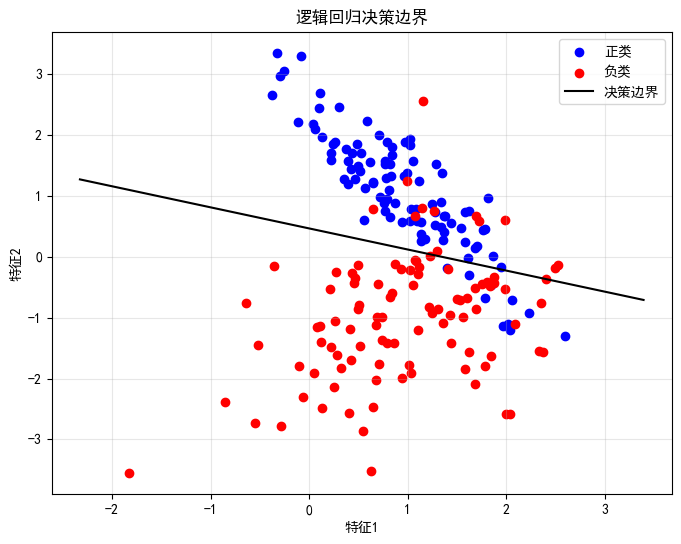

In [ ]:
#6.2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

# 生成数据（保持标签 0/1）
X, y = make_classification(n_samples=400, n_features=2, n_redundant=0, n_informative=2,
                           n_clusters_per_class=1, flip_y=0, random_state=42)


# 划分
X_train, y_train = X[:200], y[:200]
X_test, y_test = X[200:], y[200:]

# 添加偏置列
X_train_aug = np.c_[np.ones(X_train.shape[0]), X_train]
X_test_aug = np.c_[np.ones(X_test.shape[0]), X_test]

# 初始化参数
w = np.random.randn(3) * 0.01

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def cross_entropy_loss(w, X, y):
    z = X @ w
    p = sigmoid(z)
    p = np.clip(p, 1e-8, 1 - 1e-8)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

# 训练
lr = 0.1
epochs = 1000
for i in range(epochs):
    z = X_train_aug @ w
    p = sigmoid(z)
    grad = X_train_aug.T @ (p - y_train) / len(y_train)
    w -= lr * grad
    if i % 200 == 0:
        loss = cross_entropy_loss(w, X_train_aug, y_train)
        print(f"Iter {i}, loss = {loss:.4f}")

# 测试
z_test = X_test_aug @ w
y_pred = (sigmoid(z_test) >= 0.5).astype(int)
accuracy = np.mean(y_pred == y_test)
print(f"\n测试集准确率: {accuracy*100:.2f}%")

# 绘图
plt.figure(figsize=(8, 6))
plt.scatter(X_train[y_train==1][:,0], X_train[y_train==1][:,1], c='blue', label='正类')
plt.scatter(X_train[y_train==0][:,0], X_train[y_train==0][:,1], c='red', label='负类')
x1_min, x1_max = X[:,0].min()-0.5, X[:,0].max()+0.5
x1 = np.linspace(x1_min, x1_max, 100)
x2 = -(w[0] + w[1]*x1) / w[2]
plt.plot(x1, x2, 'k-', label='决策边界')
plt.xlabel('特征1')
plt.ylabel('特征2')
plt.title('逻辑回归决策边界')
plt.legend()
plt.grid(alpha=0.3)
plt.show()